# 🏋️ Intel Image Classifier — Colab Training Notebook

**Adımlar:**
1. GPU aktifleştir
2. GitHub repo clone
3. Kaggle'dan veri seti indir
4. Custom CNN eğit
5. ResNet18 (Transfer Learning) eğit
6. Karşılaştırma
7. Optuna HPO
8. ONNX Export
9. Dosyaları indir

## 1. GPU Kontrolü
**Runtime > Change runtime type > GPU (T4)** seç.

In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print("⚠️ GPU bulunamadı!")
print(f"Cihaz: {device}")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
Cihaz: cuda


## 2. Projeyi Clone Et

In [3]:
REPO_URL = "https://github.com/yildizramazan/intel-image-classifier.git"  # <-- DEĞİŞTİR

!git clone {REPO_URL}
%cd intel-image-classifier
!pip install -q optuna

Cloning into 'intel-image-classifier'...
remote: Enumerating objects: 24369, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 24369 (delta 2), reused 12 (delta 1), pack-reused 24352 (from 1)
Receiving objects: 100% (24369/24369), 342.28 MiB | 57.74 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (24372/24372), done.
/content/intel-image-classifier
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.4 MB/s eta 0:00:00


## 3. Kaggle'dan Veri Seti İndir

In [4]:
!pip install -q kaggle
from google.colab import files
print("kaggle.json dosyanı yükle:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d puneet6060/intel-image-classification -p data/
!unzip -o -q data/intel-image-classification.zip -d data/
print("\n✅ Veri seti indirildi!")
!ls data/

kaggle.json dosyanı yükle:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 186MB/s]


✅ Veri seti indirildi!
intel-image-classification.zip	seg_pred  seg_test  seg_train


In [5]:
import os
TRAIN_DIR = "data/seg_train/seg_train"
TEST_DIR = "data/seg_test/seg_test"
print(f"Train: {os.path.exists(TRAIN_DIR)} | Test: {os.path.exists(TEST_DIR)}")
if os.path.exists(TRAIN_DIR):
    print(f"Sınıflar: {os.listdir(TRAIN_DIR)}")

Train: True | Test: True
Sınıflar: ['forest', 'sea', 'mountain', 'street', 'buildings', 'glacier']


## 4. Veri Pipeline

In [6]:
import sys
sys.path.insert(0, '.')

from src.data.transforms import get_train_transforms, get_test_transforms
from src.data.dataset import load_dataset, get_class_distribution, CLASS_NAMES
from src.data.dataloader import create_dataloaders

train_dataset = load_dataset(TRAIN_DIR, transform=get_train_transforms())
test_dataset = load_dataset(TEST_DIR, transform=get_test_transforms())

dist = get_class_distribution(train_dataset)
print(f"\nSınıf dağılımı: {dist}")

Veri seti yüklendi: data/seg_train/seg_train
  Toplam görüntü sayısı: 14034
  Sınıflar: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
  Sınıf -> İndeks: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Veri seti yüklendi: data/seg_test/seg_test
  Toplam görüntü sayısı: 3000
  Sınıflar: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
  Sınıf -> İndeks: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}

Sınıf dağılımı: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}


In [7]:
BATCH_SIZE = 32
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, test_dataset, batch_size=BATCH_SIZE, val_split=0.2, num_workers=2
)

images, labels = next(iter(train_loader))
print(f"Batch: {images.shape} | Labels: {labels.shape}")

Veri seti bölümleme:
  Eğitim (Train):     11228 görüntü
  Doğrulama (Val):    2806 görüntü
  Test:               3000 görüntü
  Batch boyutu:       32
Batch: torch.Size([32, 3, 224, 224]) | Labels: torch.Size([32])


## 5. Custom CNN Eğitimi

In [9]:
import torch.nn as nn
import time
from src.models.custom_cnn import CustomCNN
from src.training.optimizer_factory import create_optimizer, create_scheduler
from src.training.trainer import Trainer

custom_model = CustomCNN(num_classes=6, num_blocks=4, base_filters=32, dropout_rate=0.3)
print(f"Parametre sayısı: {custom_model.count_parameters()}")

criterion = nn.CrossEntropyLoss()
optimizer = create_optimizer(custom_model, 'Adam', learning_rate=1e-3)
scheduler = create_scheduler(optimizer, step_size=5, gamma=0.5)

trainer = Trainer(custom_model, criterion, optimizer, device, scheduler, 'models')

t0 = time.time()
custom_history = trainer.fit(train_loader, val_loader, num_epochs=20, early_stopping_patience=5, model_name='custom_cnn')
custom_time = time.time() - t0
print(f"Süre: {custom_time:.1f}s")

Parametre sayısı: {'total': 587398, 'trainable': 587398, 'non_trainable': 0}
Epoch [1/20] Train Loss: 1.7242 | Train Acc: 0.4121 | Val Loss: 1.1050 | Val Acc: 0.5192 | LR: 0.001000 | Süre: 57.6s
  ✓ En iyi model kaydedildi: models/custom_cnn_best.pt (Acc: 0.5192)
Epoch [2/20] Train Loss: 1.1714 | Train Acc: 0.5128 | Val Loss: 0.9253 | Val Acc: 0.6126 | LR: 0.001000 | Süre: 56.6s
  ✓ En iyi model kaydedildi: models/custom_cnn_best.pt (Acc: 0.6126)
Epoch [3/20] Train Loss: 1.0419 | Train Acc: 0.5833 | Val Loss: 0.8948 | Val Acc: 0.6140 | LR: 0.001000 | Süre: 57.5s
  ✓ En iyi model kaydedildi: models/custom_cnn_best.pt (Acc: 0.6140)
Epoch [4/20] Train Loss: 0.9612 | Train Acc: 0.6124 | Val Loss: 0.8438 | Val Acc: 0.6486 | LR: 0.001000 | Süre: 56.0s
  ✓ En iyi model kaydedildi: models/custom_cnn_best.pt (Acc: 0.6486)
Epoch [5/20] Train Loss: 0.8855 | Train Acc: 0.6599 | Val Loss: 0.7977 | Val Acc: 0.6661 | LR: 0.000500 | Süre: 55.8s
  ✓ En iyi model kaydedildi: models/custom_cnn_best.pt (A

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(custom_history['train_loss'], label='Train', color='#6366f1', lw=2)
ax1.plot(custom_history['val_loss'], label='Val', color='#f43f5e', lw=2)
ax1.set_title('Custom CNN — Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(custom_history['train_acc'], label='Train', color='#6366f1', lw=2)
ax2.plot(custom_history['val_acc'], label='Val', color='#10b981', lw=2)
ax2.set_title('Custom CNN — Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"En iyi Val Accuracy: {max(custom_history['val_acc']):.4f}")

## 6. ResNet18 Transfer Learning Eğitimi

In [11]:
from src.models.transfer_model import TransferResNet18

resnet_model = TransferResNet18(num_classes=6, dropout_rate=0.3, freeze_backbone=True, unfreeze_last_n=1)
print(f"Parametre sayısı: {resnet_model.count_parameters()}")

criterion = nn.CrossEntropyLoss()
optimizer = create_optimizer(resnet_model, 'Adam', learning_rate=5e-4)
scheduler = create_scheduler(optimizer, step_size=5, gamma=0.5)

trainer_resnet = Trainer(resnet_model, criterion, optimizer, device, scheduler, 'models')

t0 = time.time()
resnet_history = trainer_resnet.fit(train_loader, val_loader, num_epochs=15, early_stopping_patience=5, model_name='resnet18')
resnet_time = time.time() - t0
print(f"Süre: {resnet_time:.1f}s")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Parametre sayısı: {'total': 11309382, 'trainable': 8526598, 'non_trainable': 2782784}
Epoch [1/15] Train Loss: 0.3842 | Train Acc: 0.8679 | Val Loss: 0.2660 | Val Acc: 0.9095 | LR: 0.000500 | Süre: 56.6s
  ✓ En iyi model kaydedildi: models/resnet18_best.pt (Acc: 0.9095)
Epoch [2/15] Train Loss: 0.2879 | Train Acc: 0.8991 | Val Loss: 0.2474 | Val Acc: 0.9116 | LR: 0.000500 | Süre: 55.4s
  ✓ En iyi model kaydedildi: models/resnet18_best.pt (Acc: 0.9116)
Epoch [3/15] Train Loss: 0.2600 | Train Acc: 0.9112 | Val Loss: 0.2418 | Val Acc: 0.9152 | LR: 0.000500 | Süre: 55.7s
  ✓ En iyi model kaydedildi: models/resnet18_best.pt (Acc: 0.9152)
Epoch [4/15] Train Loss: 0.2398 | Train Acc: 0.9178 | Val Loss: 0.2485 | Val Acc: 0.9170 | LR: 0.000500 | Süre: 56.6s
  ✓ En iyi model kaydedildi: models/resnet18_best.pt (Acc: 0.9170)
Epoch [5/15] Train Loss: 0.2189 | Train Acc: 0.9275 | Val Loss: 0.2288 | Val Acc: 0.9205 | LR: 0.000250 | Süre: 56.3s
  ✓ En iyi model kaydedildi: models/resnet18_best.pt (Ac

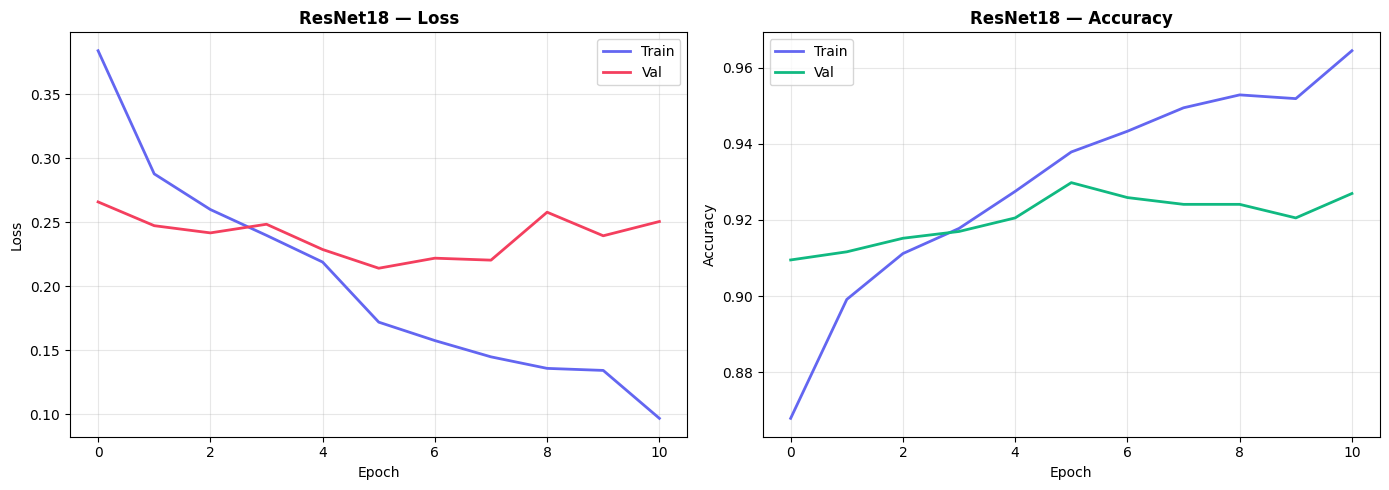

En iyi Val Accuracy: 0.9298


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(resnet_history['train_loss'], label='Train', color='#6366f1', lw=2)
ax1.plot(resnet_history['val_loss'], label='Val', color='#f43f5e', lw=2)
ax1.set_title('ResNet18 — Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(resnet_history['train_acc'], label='Train', color='#6366f1', lw=2)
ax2.plot(resnet_history['val_acc'], label='Val', color='#10b981', lw=2)
ax2.set_title('ResNet18 — Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"En iyi Val Accuracy: {max(resnet_history['val_acc']):.4f}")

## 7. Karşılaştırma

In [13]:
from src.evaluation.metrics import calculate_f1, classification_summary, compute_confusion_matrix
import seaborn as sns

trainer.load_best_model('custom_cnn')
trainer_resnet.load_best_model('resnet18')

f1_custom = calculate_f1(custom_model, test_loader, device)
f1_resnet = calculate_f1(resnet_model, test_loader, device)

print('=' * 50)
print(f'Custom CNN  — Val Acc: {max(custom_history["val_acc"]):.4f} | F1: {f1_custom:.4f}')
print(f'ResNet18    — Val Acc: {max(resnet_history["val_acc"]):.4f} | F1: {f1_resnet:.4f}')
print('=' * 50)

print('\n--- Custom CNN ---')
print(classification_summary(custom_model, test_loader, device, CLASS_NAMES))
print('\n--- ResNet18 ---')
print(classification_summary(resnet_model, test_loader, device, CLASS_NAMES))

En iyi model yüklendi: models/custom_cnn_best.pt
En iyi model yüklendi: models/resnet18_best.pt
Custom CNN  — Val Acc: 0.8325 | F1: 0.8490
ResNet18    — Val Acc: 0.9298 | F1: 0.9341

--- Custom CNN ---
              precision    recall  f1-score   support

   buildings     0.7823    0.8719    0.8247       437
      forest     0.9608    0.9831    0.9718       474
     glacier     0.7894    0.8336    0.8109       553
    mountain     0.7852    0.8076    0.7962       525
         sea     0.9097    0.8098    0.8568       510
      street     0.8911    0.8004    0.8433       501

    accuracy                         0.8487      3000
   macro avg     0.8531    0.8511    0.8506      3000
weighted avg     0.8522    0.8487    0.8490      3000


--- ResNet18 ---
              precision    recall  f1-score   support

   buildings     0.9304    0.9176    0.9240       437
      forest     0.9958    0.9958    0.9958       474
     glacier     0.8895    0.8879    0.8887       553
    mountain     0.9

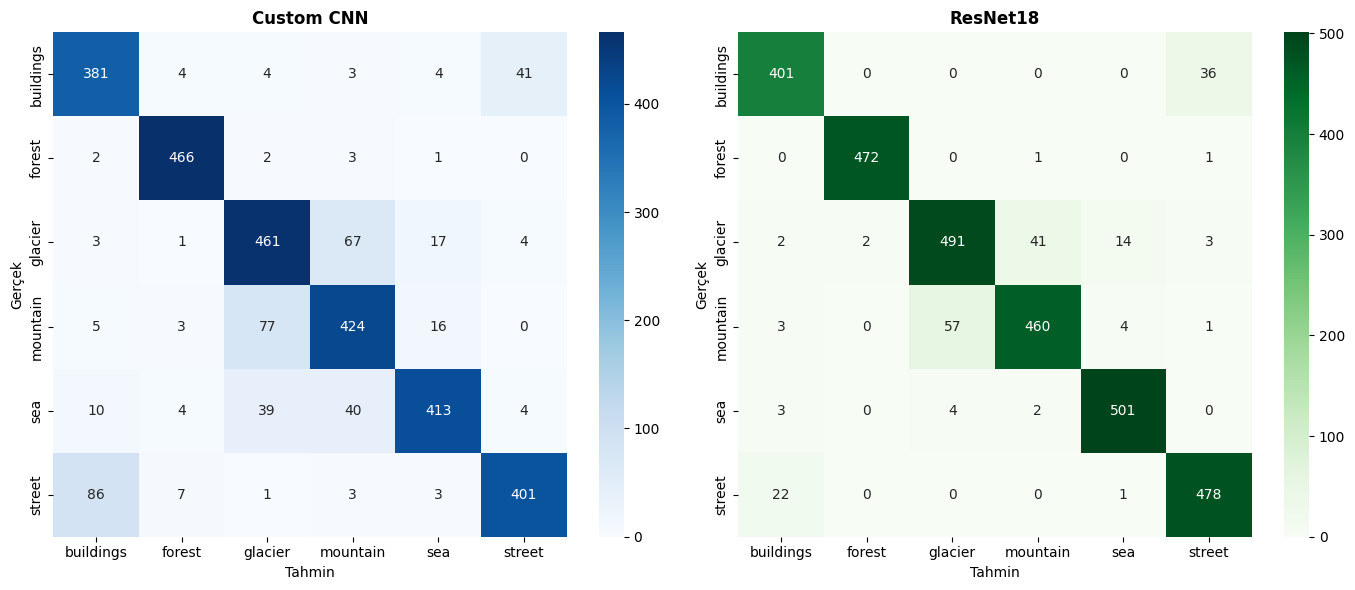

In [14]:
cm_custom = compute_confusion_matrix(custom_model, test_loader, device)
cm_resnet = compute_confusion_matrix(resnet_model, test_loader, device)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Custom CNN', fontweight='bold'); ax1.set_xlabel('Tahmin'); ax1.set_ylabel('Gerçek')

sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title('ResNet18', fontweight='bold'); ax2.set_xlabel('Tahmin'); ax2.set_ylabel('Gerçek')
plt.tight_layout(); plt.show()

## 8. Sonuçları JSON'a Kaydet
Streamlit Model Comparison sayfası bu dosyayı okuyacak.

In [15]:
import json

results = {
    'custom_cnn': {
        'val_accuracy': max(custom_history['val_acc']),
        'val_f1_score': f1_custom,
        'train_loss': custom_history['train_loss'][-1],
        'val_loss': min(custom_history['val_loss']),
        'training_time_sec': custom_time,
        'total_params': custom_model.count_parameters()['total'],
        'trainable_params': custom_model.count_parameters()['trainable'],
        'history': custom_history
    },
    'resnet18': {
        'val_accuracy': max(resnet_history['val_acc']),
        'val_f1_score': f1_resnet,
        'train_loss': resnet_history['train_loss'][-1],
        'val_loss': min(resnet_history['val_loss']),
        'training_time_sec': resnet_time,
        'total_params': resnet_model.count_parameters()['total'],
        'trainable_params': resnet_model.count_parameters()['trainable'],
        'history': resnet_history
    }
}

with open('models/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('✅ Sonuçlar models/results.json dosyasına kaydedildi!')

✅ Sonuçlar models/results.json dosyasına kaydedildi!


## 9. Optuna HPO (Opsiyonel)
GPU zamanı yer, dikkatli kullan.

In [16]:
from src.training.hpo import run_hpo_study

hpo_results = run_hpo_study(
    train_loader=train_loader, val_loader=val_loader,
    model_type='custom_cnn', device=device,
    n_trials=10, num_epochs=10
)
print(f"\nEn iyi parametreler: {hpo_results['best_params']}")
print(f"En iyi accuracy: {hpo_results['best_value']:.4f}")

[I 2026-05-19 09:19:23,395] A new study created in memory with name: intel_image_hpo



Optuna HPO Başlatılıyor
Model: custom_cnn | Deneme Sayısı: 10 | Epoch/Deneme: 10



  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-19 09:28:47,607] Trial 0 finished with value: 0.6806842480399145 and parameters: {'learning_rate': 7.631496744160099e-05, 'optimizer': 'SGD', 'dropout_rate': 0.15000000000000002, 'num_blocks': 3, 'base_filters': 64}. Best is trial 0 with value: 0.6806842480399145.
[W 2026-05-19 09:29:06,364] Trial 1 failed with parameters: {'learning_rate': 1.1535799060708528e-05, 'optimizer': 'SGD', 'dropout_rate': 0.5, 'num_blocks': 3, 'base_filters': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/content/intel-image-classifier/src/training/hpo.py", line 178, in <lambda>
    lambda trial: objective(
                  ^^^^^^^^^^
  File "/content/intel-image-classifier/src/training/hpo.py", line 114, in objective
    history = trainer.fit(
              ^^^^^^^^^^^^
  File 

KeyboardInterrupt: 

In [ ]:
# En iyi parametrelerle final eğitim
best_p = hpo_results['best_params']
final_model = CustomCNN(num_classes=6, num_blocks=best_p.get('num_blocks', 4),
                        base_filters=best_p.get('base_filters', 32),
                        dropout_rate=best_p.get('dropout_rate', 0.3))

optimizer = create_optimizer(final_model, best_p.get('optimizer', 'Adam'), best_p['learning_rate'])
scheduler = create_scheduler(optimizer)
final_trainer = Trainer(final_model, nn.CrossEntropyLoss(), optimizer, device, scheduler)

final_history = final_trainer.fit(train_loader, val_loader, num_epochs=25,
                                  early_stopping_patience=7, model_name='custom_cnn_best')
print(f"Final Accuracy: {max(final_history['val_acc']):.4f}")

## 10. ONNX Export

In [18]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.0 MB/s eta 0:00:00


In [19]:
from src.export.onnx_export import export_to_onnx, verify_onnx_model

trainer.load_best_model('custom_cnn')
export_to_onnx(custom_model, 'models/custom_cnn.onnx')
verify_onnx_model('models/custom_cnn.onnx')

trainer_resnet.load_best_model('resnet18')
export_to_onnx(resnet_model, 'models/resnet18.onnx')
verify_onnx_model('models/resnet18.onnx')

En iyi model yüklendi: models/custom_cnn_best.pt


/content/intel-image-classifier/src/export/onnx_export.py:61: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0519 09:30:57.672000 2616 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0519 09:30:58.666000 2616 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int',

[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX modeli kaydedildi: models/custom_cnn.onnx (0.03 MB)
✗ ONNX doğrulama hatası: No module named 'onnxruntime'
En iyi model yüklendi: models/resnet18_best.pt


W0519 09:31:02.109000 2616 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0519 09:31:02.111000 2616 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0519 09:31:02.112000 2616 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0519 09:31:02.114000 2616 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `TransferResNet18([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TransferResNet18([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX modeli kaydedildi: models/resnet18.onnx (0.11 MB)
✗ ONNX doğrulama hatası: No module named 'onnxruntime'


False

## 11. Dosyaları İndir

In [20]:
from google.colab import files

for f in ['models/custom_cnn_best.pt', 'models/resnet18_best.pt',
          'models/custom_cnn.onnx', 'models/resnet18.onnx',
          'models/results.json']:
    if os.path.exists(f):
        files.download(f)
        print(f'  ✅ {f}')
    else:
        print(f'  ⚠️ {f} bulunamadı')

print('\n🎉 Dosyaları lokal projendeki models/ klasörüne kopyala.')
print('Sonra: streamlit run app/app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ models/custom_cnn_best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ models/resnet18.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ models/results.json

🎉 Dosyaları lokal projendeki models/ klasörüne kopyala.
Sonra: streamlit run app/app.py
